# IMPORTS, CONSTANTS AND FUNCTIONS

In [219]:
# Import all necessaty libraries
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import IPython.display as ipd
import control as ctrl
import warnings
from scipy.signal import residuez
from scipy.io.wavfile import write
import librosa
import librosa.display

In [220]:
FS = 10000       # Sampling Rate
NFFT = 2048      # Number of points in FFT

NP = 80          # Impulse Train Period
BETA = 0.9999    # Amplitude of Impulses
N = 63           # Length of Impulse Train (Set at 63 in order to achieve an impulse train of 0.5sec duration)

A = 5000         # Constant Gain

# For the Glottal Pulse
N1 = 25
N2 = 10

# For the Vocal Tract
K = 3            # Number of Formants
T = 10**(-4)

# For the Radiation Load
GAMMA = 0.96

In [221]:
# This function creates the transfer function of a system, and plots the poles and zeros of it
def pole_zero_diagram(num, den, title):
    system = ctrl.TransferFunction(num, den, True) # Transfer Function

    # Calculate and count the zeros and the poles at the origin, to show it on the plots
    zeros = np.roots(num)
    poles = np.roots(den)
    zeros_at_origin = np.sum(np.isclose(zeros, 0))
    poles_at_origin = np.sum(np.isclose(poles, 0))

    # Plot the Pole-Zero Diagram
    plt.figure(figsize=(8, 6))

    # Plot the unit circle for reference (center (0, 0) and radius = 1)
    plt.Circle((0, 0), 1, color='black', fill=False, linestyle='-')

    # Plot the Zeros and the Poles
    ctrl.pzmap(system, plot=True, title='')

    # Show the number of zeros in the center
    if (np.sum(zeros_at_origin) > 0) and (zeros_at_origin > poles_at_origin):
        plt.text(0.02, -0.1, f'{zeros_at_origin}', fontsize=10)
    
    if (np.sum(poles_at_origin) > 0) and (poles_at_origin > zeros_at_origin):
        plt.text(0.02, -0.1, f'{poles_at_origin}', fontsize=10)

    # Remove an unnecessary warning
    warnings.filterwarnings("ignore", category=FutureWarning)

    plt.title(title)
    plt.grid()
    plt.show()

In [222]:
# Create the Transfer Function of the Vocal Tract, V(z) of each vowel
# It takes as input an array which conatins the formants of the vowel, and returns the samples (x-axis of the plot), vn (vocal tract signal in time domain), 
#     vz_num, vz_den: numerator/denominator of the transfer function and vn_fft_magn, the magnitude of the signal in frequency domain

def vocal_tract_transfer_func(formant):
    z = sp.symbols('z')

    two_sk = [60, 100, 120]

    v_den = 1
    for i in range(K):
        v_den *= (1 - 2*np.exp(-1 * np.pi * T * two_sk[i]) * np.cos(2 * np.pi * formant[i] * T) * z**(-1) + np.exp(-2 * np.pi * T * two_sk[i]) * z**(-2))
        
    v_den_expanded = sp.expand(v_den) # Perform the Multiplications to create a degree 6 polynomial

    # Convert the Vocal Tract Frequency Responce to Time Domain
    # Numerator Coefficient: [1, 0, 0, 0, 0, 0, 0]
    vz_num = np.zeros(2*K + 1)
    vz_num[0] = 1

    # Denominator Coefficients: Located in v_den_expanded list, reverse its order and convert it to a numpy array
    vz_den_list = list(reversed(v_den_expanded.as_poly().all_coeffs())) # list(reversed()) => Reverses the list, .as_poly().all_coeffs() => Extracts the Coeffs
    vz_den = np.array(vz_den_list, dtype=float)

    r, p, _ = residuez(vz_num, vz_den) # Compute Partial Fractions

    # Define the number of time samples
    samples = np.linspace(0, 251, 251)

    # Compute the inverse Z-transform (sum of residue-pole contributions)
    vn = np.zeros_like(samples, dtype=complex)
    for i in range(len(r)):
        vn += r[i] * p[i]**samples  # Each residue-pole term: r_i * p_i^n
        
    # Find the Frequency Responce V(e^(jω)) of the Vocal Tract
    vn_fft = np.fft.fft(vn, NFFT)
    vn_fft_magn = np.log(np.abs(vn_fft))

    samples = 0.1*samples # convert samples to msec
    
    return samples, np.real(vn), vz_num, vz_den, vn_fft_magn 

In [223]:
# This function finds the synthetic vowel s[n] by performing the convolution: s[n] = A(p[n] * g[n] * v[n] * r[n])
# It returns the synthetic vowel sn and its frequency response

def find_sn(A, pn, gn, vn, rn):
    sn = A*(np.convolve(np.convolve(np.convolve(pn, gn), vn), rn))
    
    # Convert it to Frequency Domain
    sn_fft = np.abs(np.fft.fft(sn, NFFT))
    sn_fft_magn = np.log(np.abs(sn_fft))
    return sn, sn_fft_magn

In [224]:
# This function creates the pole-zero diagram of the synthetic vowel signal by performing polynomial multiplication of the numerator and the denominatorm sepertely
# Then, it uses the 'pole_zero_diagram' function to plot the diagram

def pole_zero_diagram_of_sz(pz_num, pz_den, gz_num, gz_den, vz_num, vz_den, rz_num, rz_den, vowel):
    
    # Convolution corresponds to polynomial multiplication
    sz_num = np.convolve(np.convolve(np.convolve(pz_num, gz_num), vz_num), rz_num) # Convolution of all numerators to compute the numerator of S(z)
    sz_den = np.convolve(np.convolve(np.convolve(pz_den, gz_den), vz_den), rz_den) # Convolution of all denumerators to compute the denumerator of S(z)

    # Remove undesired zeros at the end of the numerator
    for i in range(len(sz_num)-1, 0, -1):
        if sz_num[i] == 0: # As long as the last element is 0, remove it from the list
            sz_num = np.delete(sz_num, -1)
        else: # If a non-zero entry is found, exit from the loop => No need for further removal
            break
        
    # And from the denominator
    for i in range(len(sz_den)-1, 0, -1):
        if sz_den[i] == 0:
            sz_den = np.delete(sz_den, -1)
        else:
            break
        
    # Now append zeros to the smaller vector so make them have the same length (and print the number of zeros/poles at the origin)
    if (sz_num.size < sz_den.size):
        for i in range(sz_num.size, sz_den.size):
            sz_num = np.insert(sz_num, i, 0)
        
    if (sz_num.size > sz_den.size):
        for i in range(sz_den.size, sz_num.size):
            sz_den = np.insert(sz_den, i, 0)

    pole_zero_diagram(sz_num, sz_den, f'Pole Zero Diagram of S(z) for the vowel {vowel}')

# CODE

In [225]:
##################    CREATE SIGNALS IN TIME DOMAIN    ##################

# Create the Periodic Excitation p[n] as an impulse train
pn = np.zeros(NP*N)

j=0
for i in range(0, N*NP, NP): # Add an Impulse every NP Samples)
    pn[i] = BETA**j
    j=j+1
    
# Create the Glottal Pulse g[n]
gn = np.zeros(N1+N2+1)

for n in range(N1):
    gn[n] = 0.5 * (1 - np.cos(np.pi * ((n+1)/N1)))
    
for n in range(N1, N1+N2-1):
    gn[n] = np.cos(0.5 * np.pi * ((n+1-N1)/N2))   
    
# And Finally, create the Radiation Load r[n]
rn = np.zeros(NP)
rn[0] = 1
rn[1] = -GAMMA


##################    CREATE SIGNALS IN FREQUENCY DOMAINS    ##################

# Find the Frequency Responce P(e^(jω)) of the Impulse Train
pn_fft = np.fft.fft(pn, NFFT)
pn_fft_magn = np.abs(pn_fft) # Magnitude of FFT of the Impulse Train

# Find the Frequency Responce G(e^(jω)) of the Glottal Pulse
gn_fft = np.fft.fft(gn, NFFT)
gn_fft_magn = np.log(np.abs(gn_fft)) # Log Magnitude of FFT of Glottal Pulse

# Find the Frequency Responce R(e^(jω)) of the Radiation Load
rn_fft = np.fft.fft(rn, NFFT)
rn_fft_magn = np.abs(rn_fft) # Log Magnitude of FFT of Radiation Load


##################    CREATE THE X-AXIS FOR THE PLOTS    ##################

t = np.linspace(0, pn.size, pn.size)
freqs = np.abs(np.fft.fftfreq(NFFT, 1/FS)) # Frequency bins, for the plots of the FFT

# For the Glottal Pulse
n = np.linspace(0, N1+N2, N1+N2+1)

# Convert all x-axis in msec
t = 0.1*t
n = 0.1*n
xrn = np.arange(0, (NP/10), 0.1)

In [226]:
# Hear the Impulse Train
ipd.Audio(pn, rate=10000)

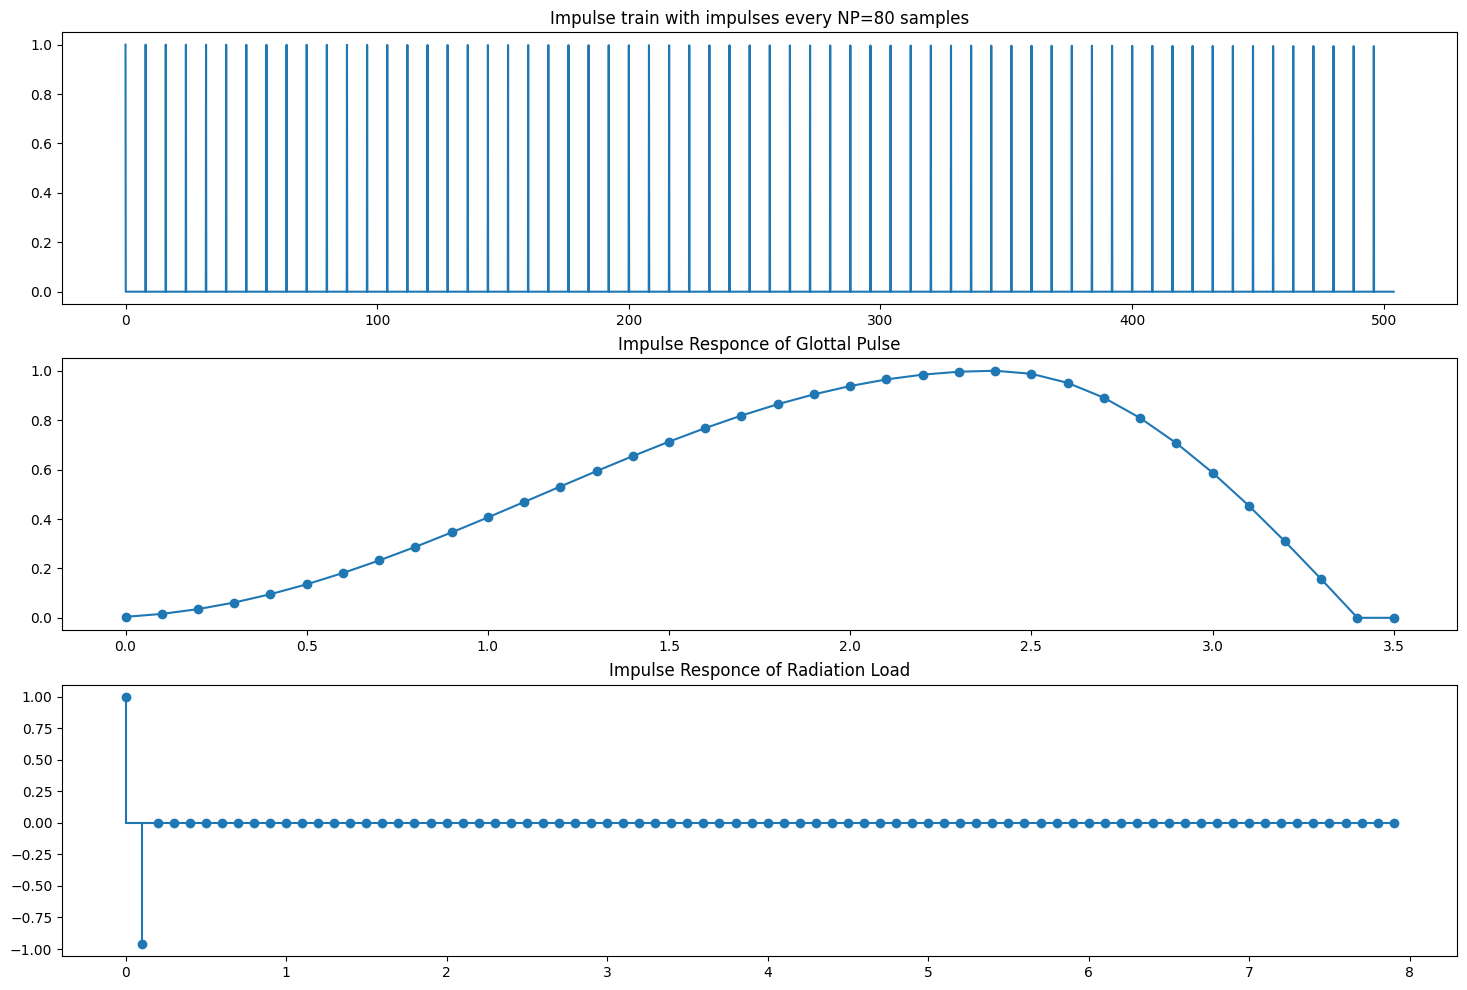

In [227]:
# PLOT THE SIGNALS IN TIME DOMAIN (ALL X-AXIS CORRESPOND TO MSEC)
plt.figure(figsize=(18, 12))

plt.subplot(3, 1, 1)
plt.plot(t, pn)
plt.title(f"Impulse train with impulses every NP={NP} samples")

plt.subplot(3, 1, 2)
plt.scatter(n, gn)
plt.plot(n, gn)
plt.title(f"Impulse Responce of Glottal Pulse")

plt.subplot(3, 1, 3)
plt.stem(xrn, rn, basefmt='-')
plt.title(f"Impulse Responce of Radiation Load")

plt.savefig("images/time_domain_signals.png")
plt.show()

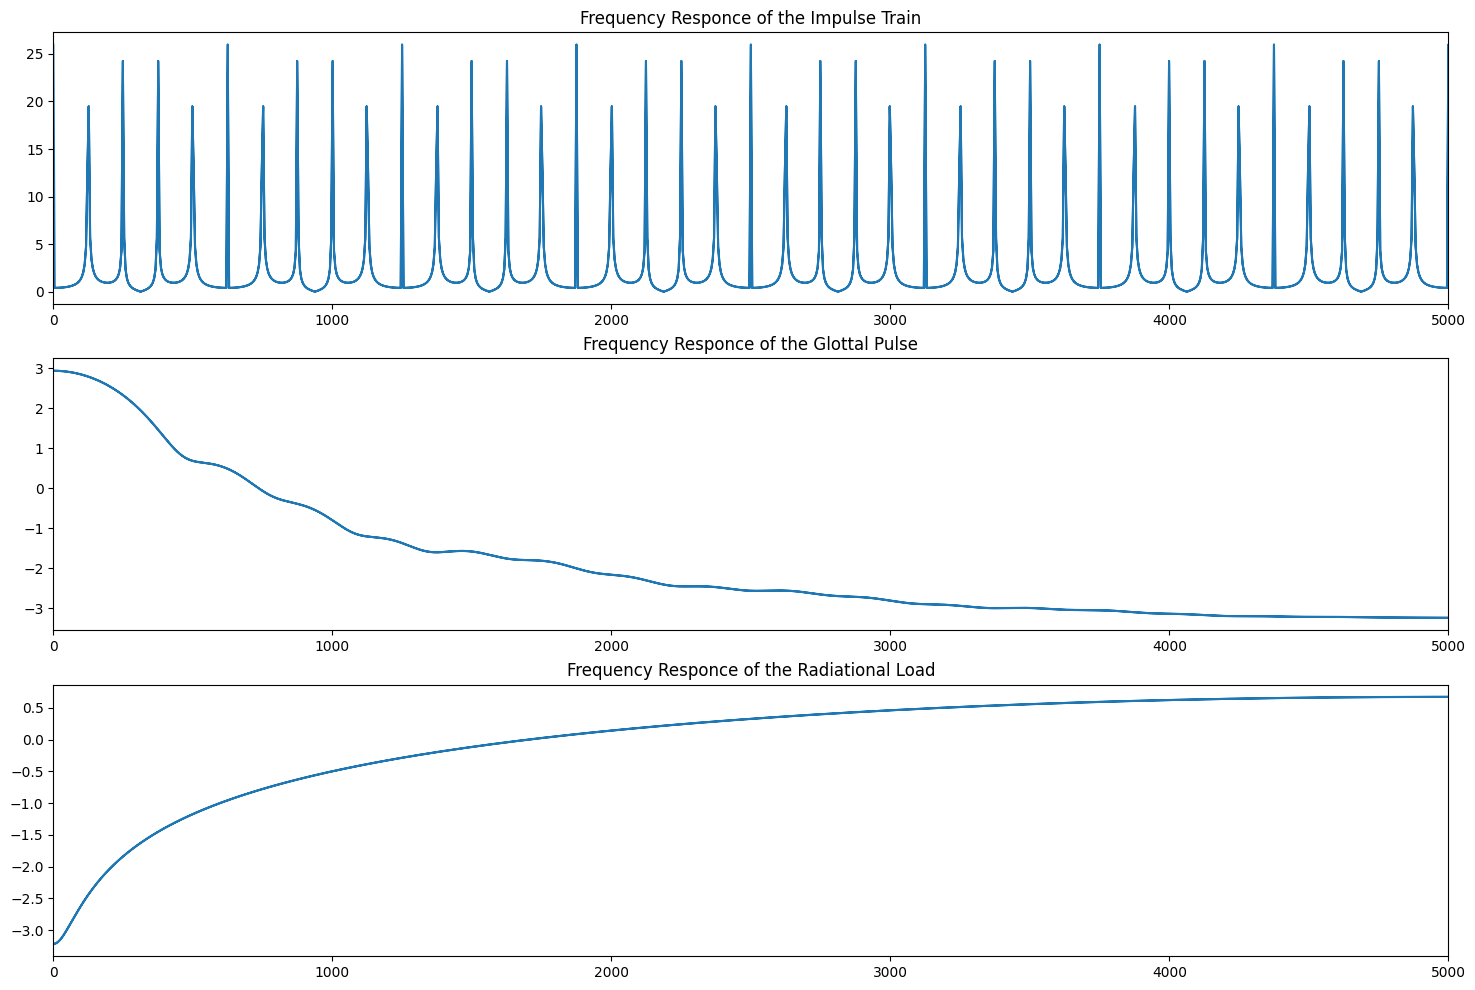

In [228]:
# PLOT THE SIGNALS IN FREQUENCY DOMAIN
plt.figure(figsize=(18, 12))

plt.subplot(3, 1, 1)
plt.plot(freqs, pn_fft_magn)
plt.title(f"Frequency Responce of the Impulse Train")
plt.xlim(0, 5000)

plt.subplot(3, 1, 2)
plt.plot(freqs, gn_fft_magn)
plt.title(f"Frequency Responce of the Glottal Pulse")
plt.xlim(0, 5000)

plt.subplot(3, 1, 3)
plt.plot(freqs, np.log(rn_fft_magn))
plt.title(f"Frequency Responce of the Radiational Load")
plt.xlim(0, 5000)

plt.savefig("images/freq_domain_signals.png")
plt.show()

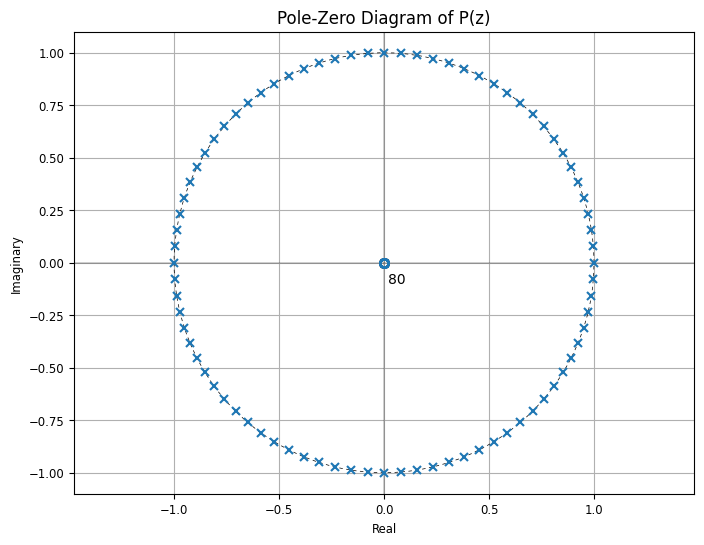

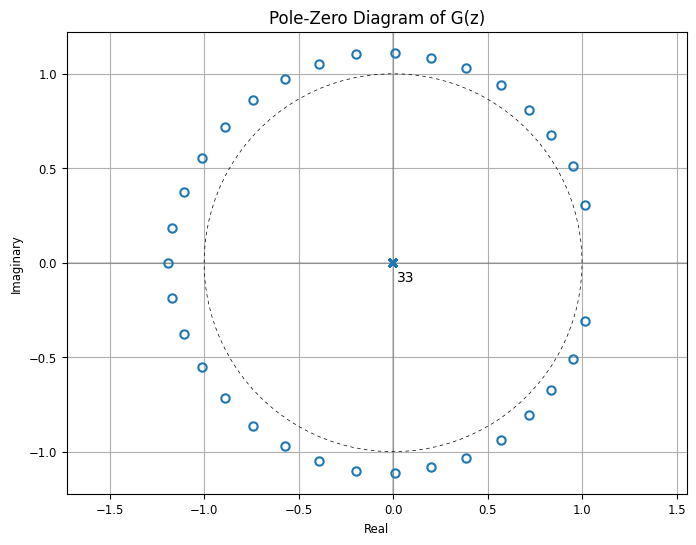

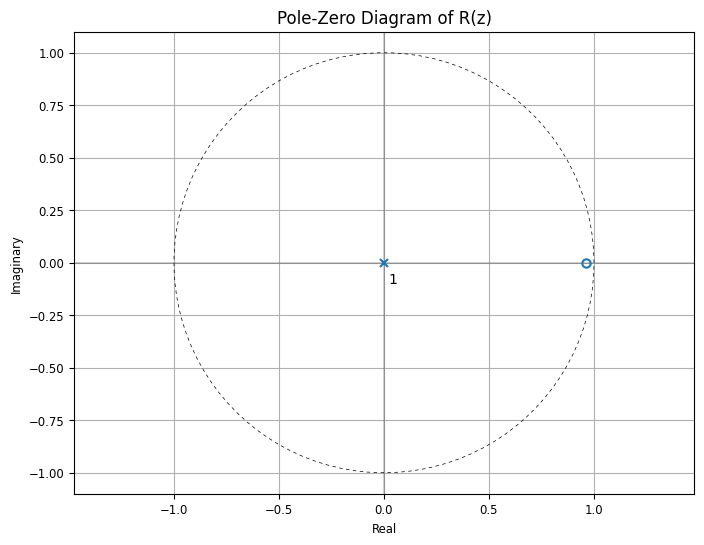

In [229]:
# CREATE AND PLOT POLE-ZERO DIAGRAMS

# Create the pole-zero diagram of P(Z) = 1 / 1 - BETA*z^(-80)
# Numerator Coefficient: [1, 0, 0, ..., 0, 0, 0]
pz_num = np.zeros(NP+1)
pz_num[0] = 1

# Denumerator Coefficients: [1, 0, 0, ..., 0, 0, -BETA]
pz_den = np.zeros(NP+1)
pz_den[0] = 1
pz_den[NP] = -1*BETA

# Create the pole-zero diagram of the Glottal Pulse G(z)
# Numerator Coefficient: [gn[0], gn[1], ..., gn[N1+N2-1]]
gz_num = gn[0:(N1+N2-1)]

# Denumerator Coefficients: [1, 0, 0, ..., 0, 0, 0] (The transferm function is polynomial, not rational)
gz_den = np.zeros(N1+N2-1)
gz_den[0] = 1

# Create the pole-zero diagram of the Radiation Load R(z)
rz_num = [1, -GAMMA]
rz_den = [1, 0]

# Use the custom-made function 'pole_zero_diagram'to plot the diagrams
pole_zero_diagram(pz_num, pz_den, 'Pole-Zero Diagram of P(z)')
pole_zero_diagram(gz_num, gz_den, 'Pole-Zero Diagram of G(z)')
pole_zero_diagram(rz_num, rz_den, 'Pole-Zero Diagram of R(z)')

In [230]:
samples_ao, vn_ao, vz_num_ao, vz_den_ao, vn_fft_magn_ao = vocal_tract_transfer_func([570, 840, 2410])  # Call the Vocal Tract Function for vowel /AO/
samples_iy, vn_iy, vz_num_iy, vz_den_iy, vn_fft_magn_iy = vocal_tract_transfer_func([270, 2290, 3010]) # Call the Vocal Tract Function for vowel /IY/
samples_uh, vn_uh, vz_num_uh, vz_den_uh, vn_fft_magn_uh = vocal_tract_transfer_func([440, 1020, 2240]) # Call the Vocal Tract Function for vowel /UH/
samples_eh, vn_eh, vz_num_eh, vz_den_eh, vn_fft_magn_eh = vocal_tract_transfer_func([530, 1840, 2480]) # Call the Vocal Tract Function for vowel /EH/
samples_ah, vn_ah, vz_num_ah, vz_den_ah, vn_fft_magn_ah = vocal_tract_transfer_func([520, 1190, 2390]) # Call the Vocal Tract Function for vowel /AH/
samples_ih, vn_ih, vz_num_ih, vz_den_ih, vn_fft_magn_ih = vocal_tract_transfer_func([390, 1990, 2550]) # Call the Vocal Tract Function for vowel /IH/

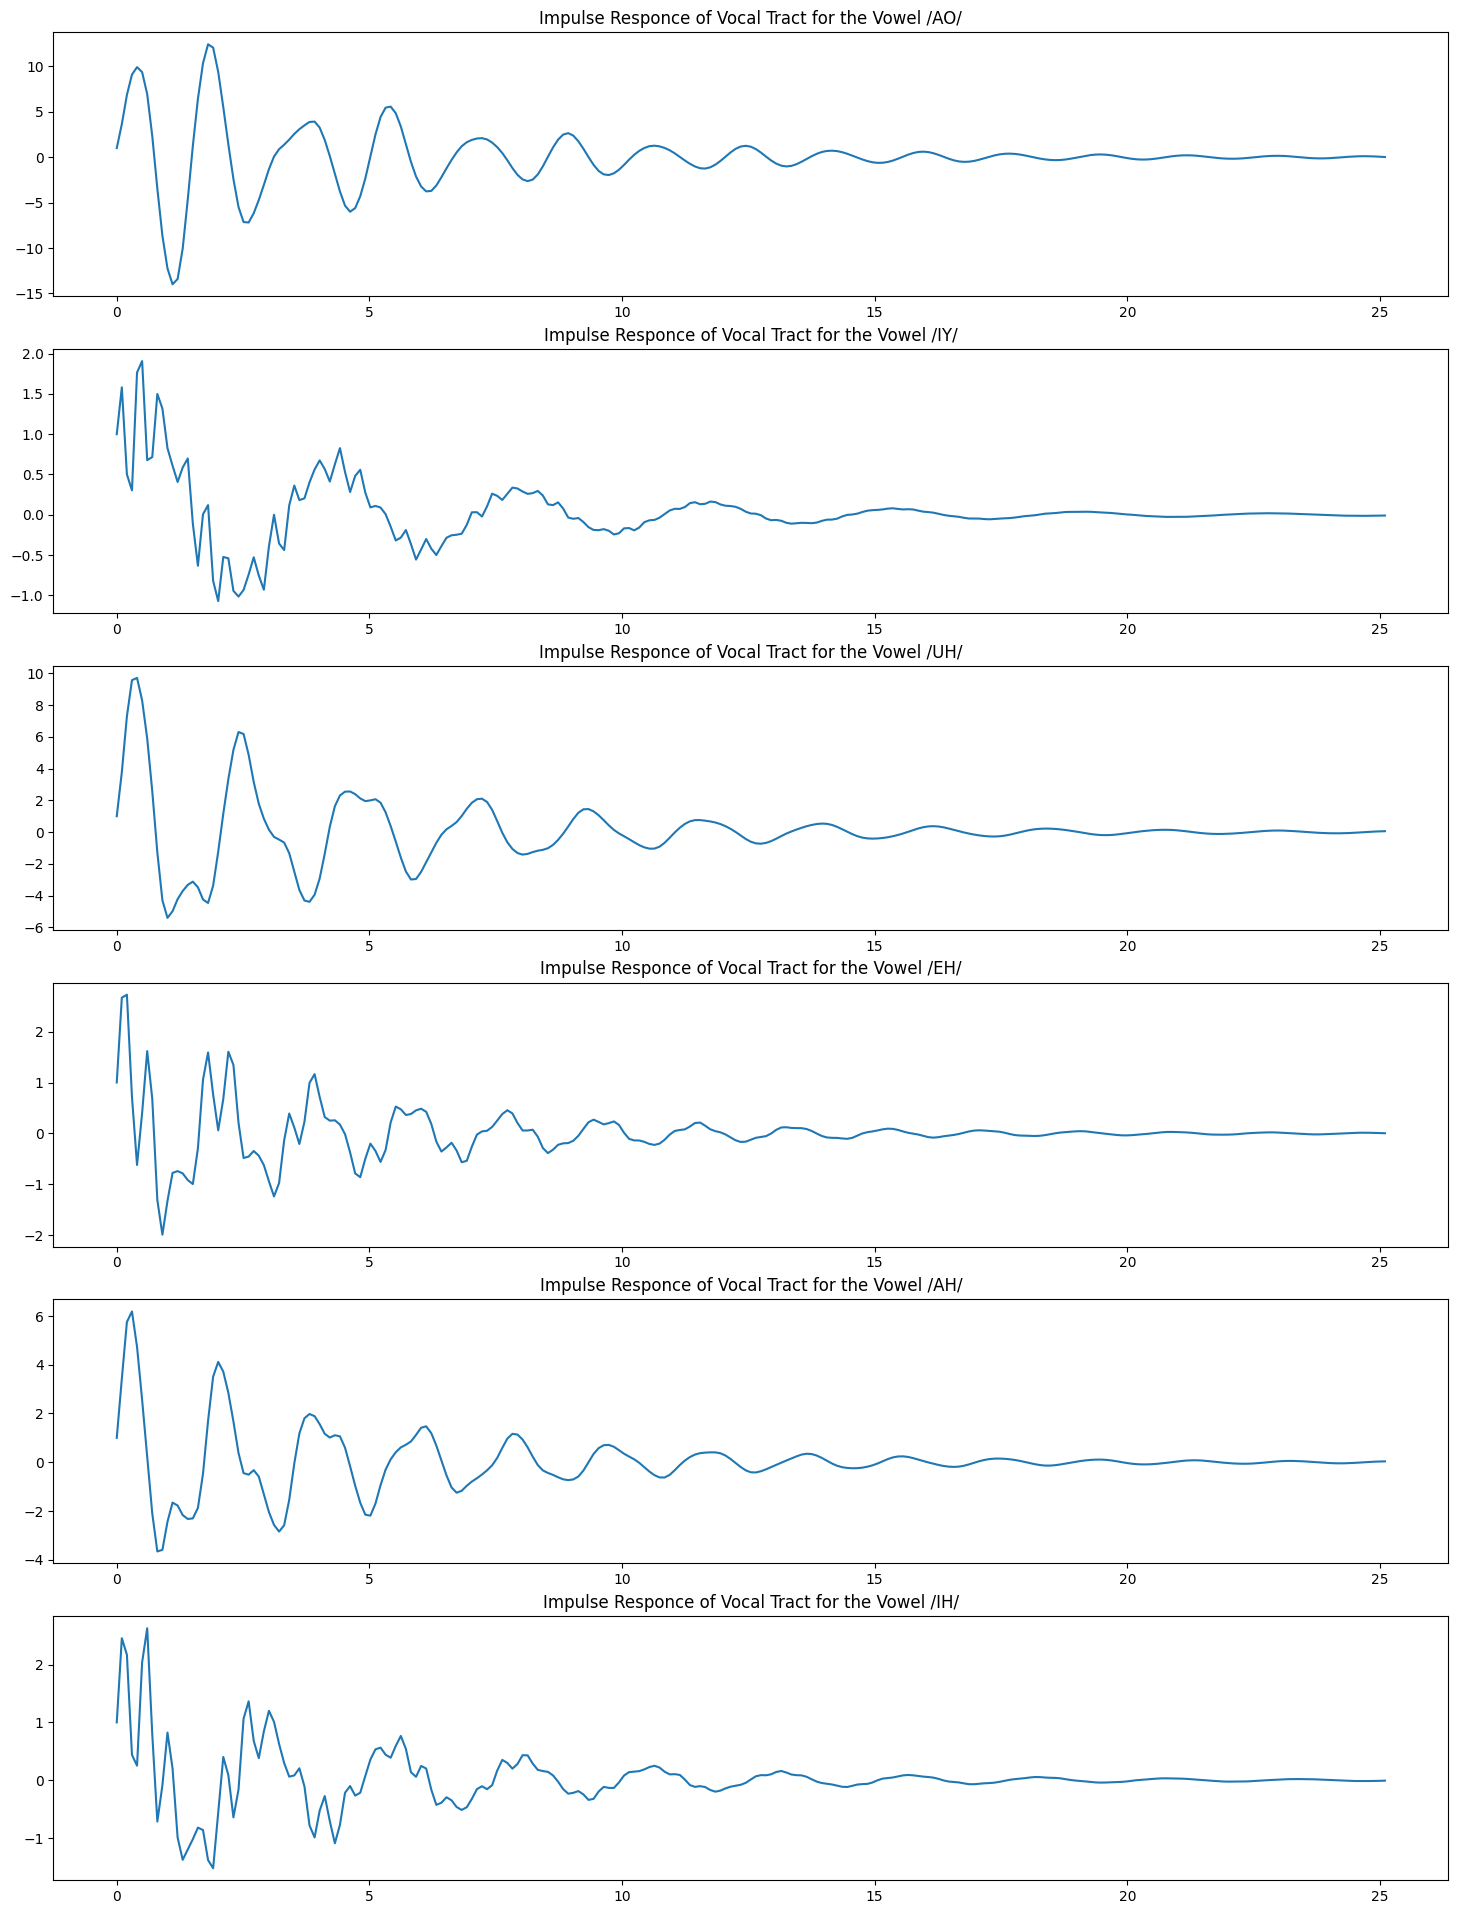

In [231]:
# PLOT VOCAL TRACT FOR EACH VOWEL IN TIME DOMAIN

plt.figure(figsize=(18, 24))

plt.subplot(6, 1, 1)
plt.plot(samples_ao, vn_ao)
plt.title(f"Impulse Responce of Vocal Tract for the Vowel /AO/")

plt.subplot(6, 1, 2)
plt.plot(samples_iy, vn_iy)
plt.title(f"Impulse Responce of Vocal Tract for the Vowel /IY/")

plt.subplot(6, 1, 3)
plt.plot(samples_uh, vn_uh)
plt.title(f"Impulse Responce of Vocal Tract for the Vowel /UH/")

plt.subplot(6, 1, 4)
plt.plot(samples_eh, vn_eh)
plt.title(f"Impulse Responce of Vocal Tract for the Vowel /EH/")

plt.subplot(6, 1, 5)
plt.plot(samples_ah, vn_ah)
plt.title(f"Impulse Responce of Vocal Tract for the Vowel /AH/")

plt.subplot(6, 1, 6)
plt.plot(samples_ih, vn_ih)
plt.title(f"Impulse Responce of Vocal Tract for the Vowel /IH/")

plt.savefig("images/vocal_tract_imp_response.png")
plt.show()

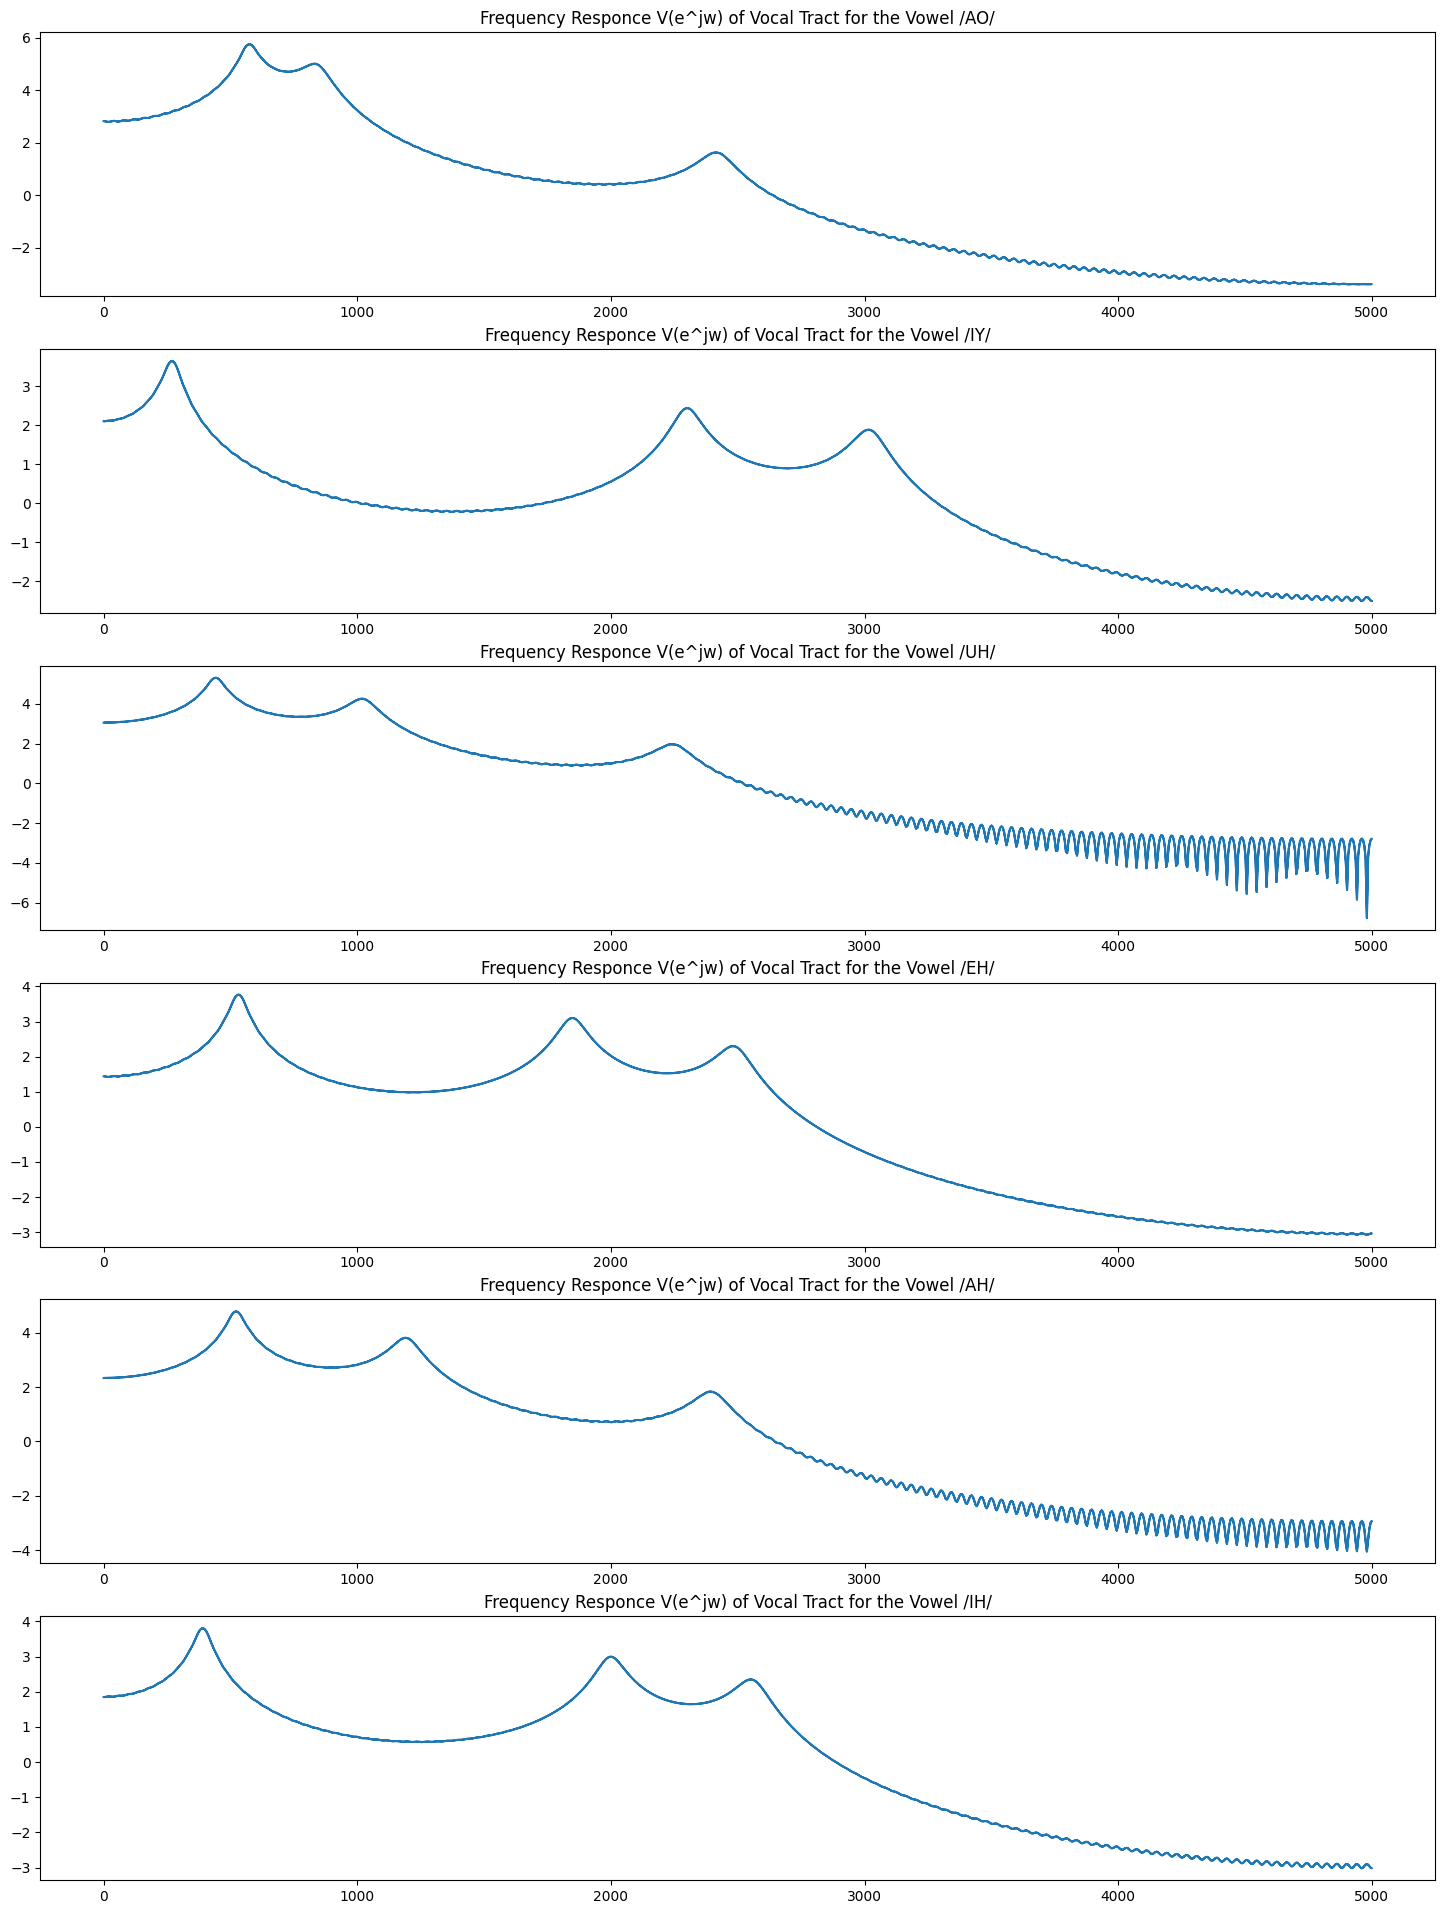

In [232]:
# PLOT VOCAL TRACT FOR EACH VOWEL IN FREQUENCY DOMAIN

plt.figure(figsize=(18, 24))

plt.subplot(6, 1, 1)
plt.plot(freqs, vn_fft_magn_ao)
plt.title(f"Frequency Responce V(e^jw) of Vocal Tract for the Vowel /AO/")

plt.subplot(6, 1, 2)
plt.plot(freqs, vn_fft_magn_iy)
plt.title(f"Frequency Responce V(e^jw) of Vocal Tract for the Vowel /IY/")

plt.subplot(6, 1, 3)
plt.plot(freqs, vn_fft_magn_uh)
plt.title(f"Frequency Responce V(e^jw) of Vocal Tract for the Vowel /UH/")

plt.subplot(6, 1, 4)
plt.plot(freqs, vn_fft_magn_eh)
plt.title(f"Frequency Responce V(e^jw) of Vocal Tract for the Vowel /EH/")

plt.subplot(6, 1, 5)
plt.plot(freqs, vn_fft_magn_ah)
plt.title(f"Frequency Responce V(e^jw) of Vocal Tract for the Vowel /AH/")

plt.subplot(6, 1, 6)
plt.plot(freqs, vn_fft_magn_ih)
plt.title(f"Frequency Responce V(e^jw) of Vocal Tract for the Vowel /IH/")

plt.savefig("images/vocal_tract_freq_response.png")
plt.show()

In [233]:
sn_ao, sn_fft_magn_ao = find_sn(A, pn, gn, vn_ao, rn) # Create the s[n] of the vowel /AO/
sn_iy, sn_fft_magn_iy = find_sn(A, pn, gn, vn_iy, rn) # Create the s[n] of the vowel /IY/
sn_uh, sn_fft_magn_uh = find_sn(A, pn, gn, vn_uh, rn) # Create the s[n] of the vowel /UH/
sn_eh, sn_fft_magn_eh = find_sn(A, pn, gn, vn_eh, rn) # Create the s[n] of the vowel /EH/
sn_ah, sn_fft_magn_ah = find_sn(A, pn, gn, vn_ah, rn) # Create the s[n] of the vowel /AH/
sn_ih, sn_fft_magn_ih = find_sn(A, pn, gn, vn_ih, rn) # Create the s[n] of the vowel /IH/

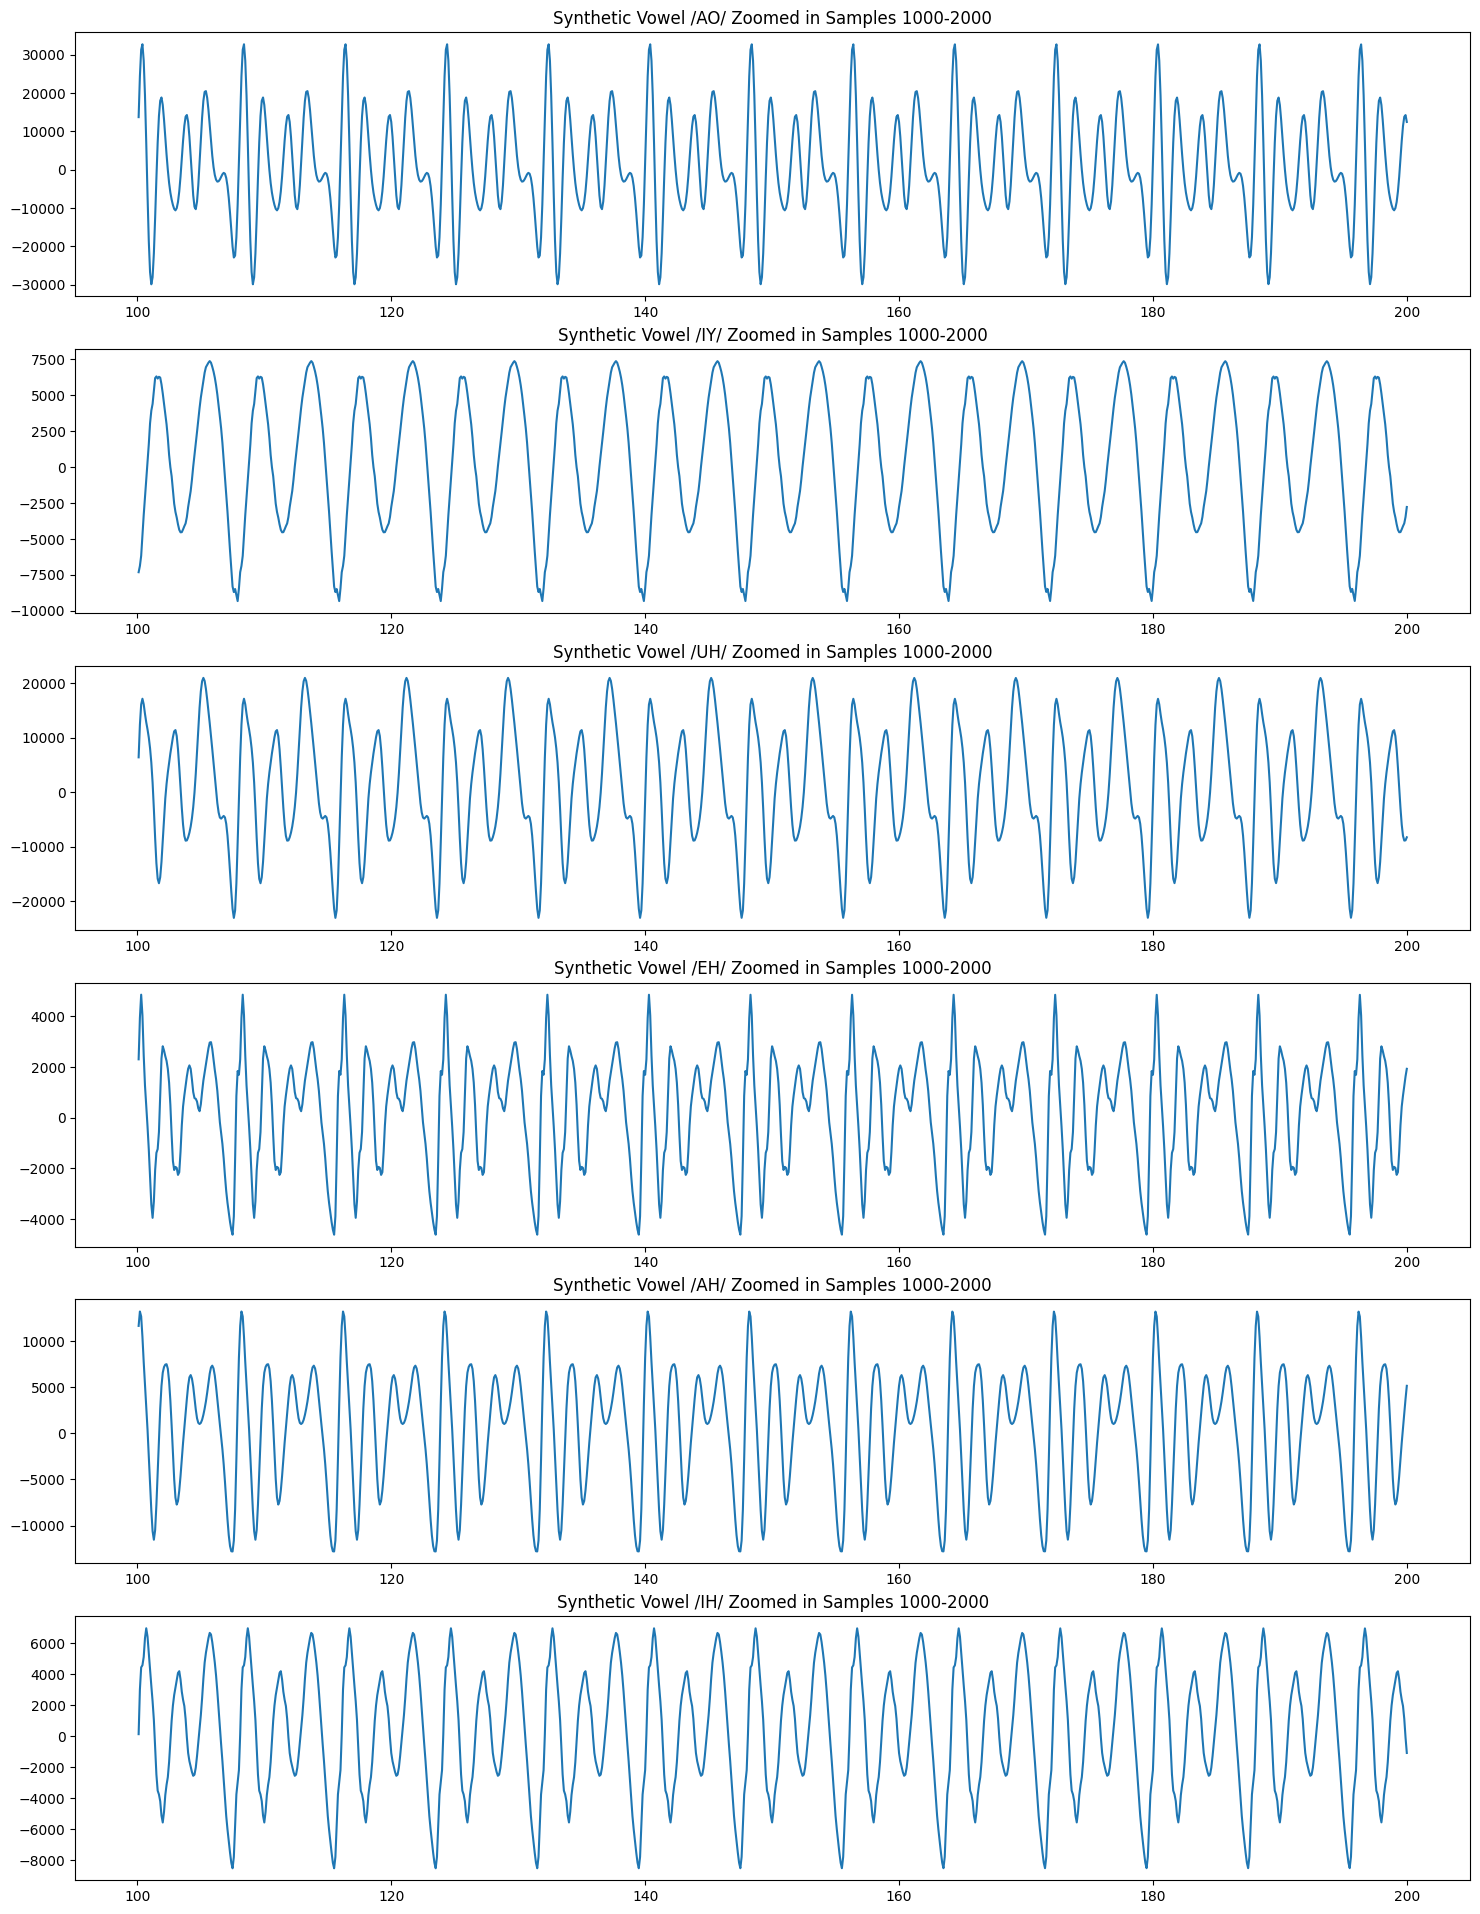

In [234]:
# PLOT ALL SYNTHETIC VOWELS IN TIME DOMAIN
td = np.linspace(1, sn_ao.size, sn_ao.size) # x-axis, since all vowels have the same length, it doesn't matter which one you will choose

plt.figure(figsize=(18, 24))

plt.subplot(6, 1, 1)
plt.plot(0.1*td[1000:2000], sn_ao[1000:2000])
plt.title("Synthetic Vowel /AO/ Zoomed in Samples 1000-2000")

plt.subplot(6, 1, 2)
plt.plot(0.1*td[1000:2000], sn_iy[1000:2000])
plt.title("Synthetic Vowel /IY/ Zoomed in Samples 1000-2000")

plt.subplot(6, 1, 3)
plt.plot(0.1*td[1000:2000], sn_uh[1000:2000])
plt.title("Synthetic Vowel /UH/ Zoomed in Samples 1000-2000")

plt.subplot(6, 1, 4)
plt.plot(0.1*td[1000:2000], sn_eh[1000:2000])
plt.title("Synthetic Vowel /EH/ Zoomed in Samples 1000-2000")

plt.subplot(6, 1, 5)
plt.plot(0.1*td[1000:2000], sn_ah[1000:2000])
plt.title("Synthetic Vowel /AH/ Zoomed in Samples 1000-2000")

plt.subplot(6, 1, 6)
plt.plot(0.1*td[1000:2000], sn_ih[1000:2000])
plt.title("Synthetic Vowel /IH/ Zoomed in Samples 1000-2000")

plt.savefig("images/synthetic_vowels.png")
plt.show()

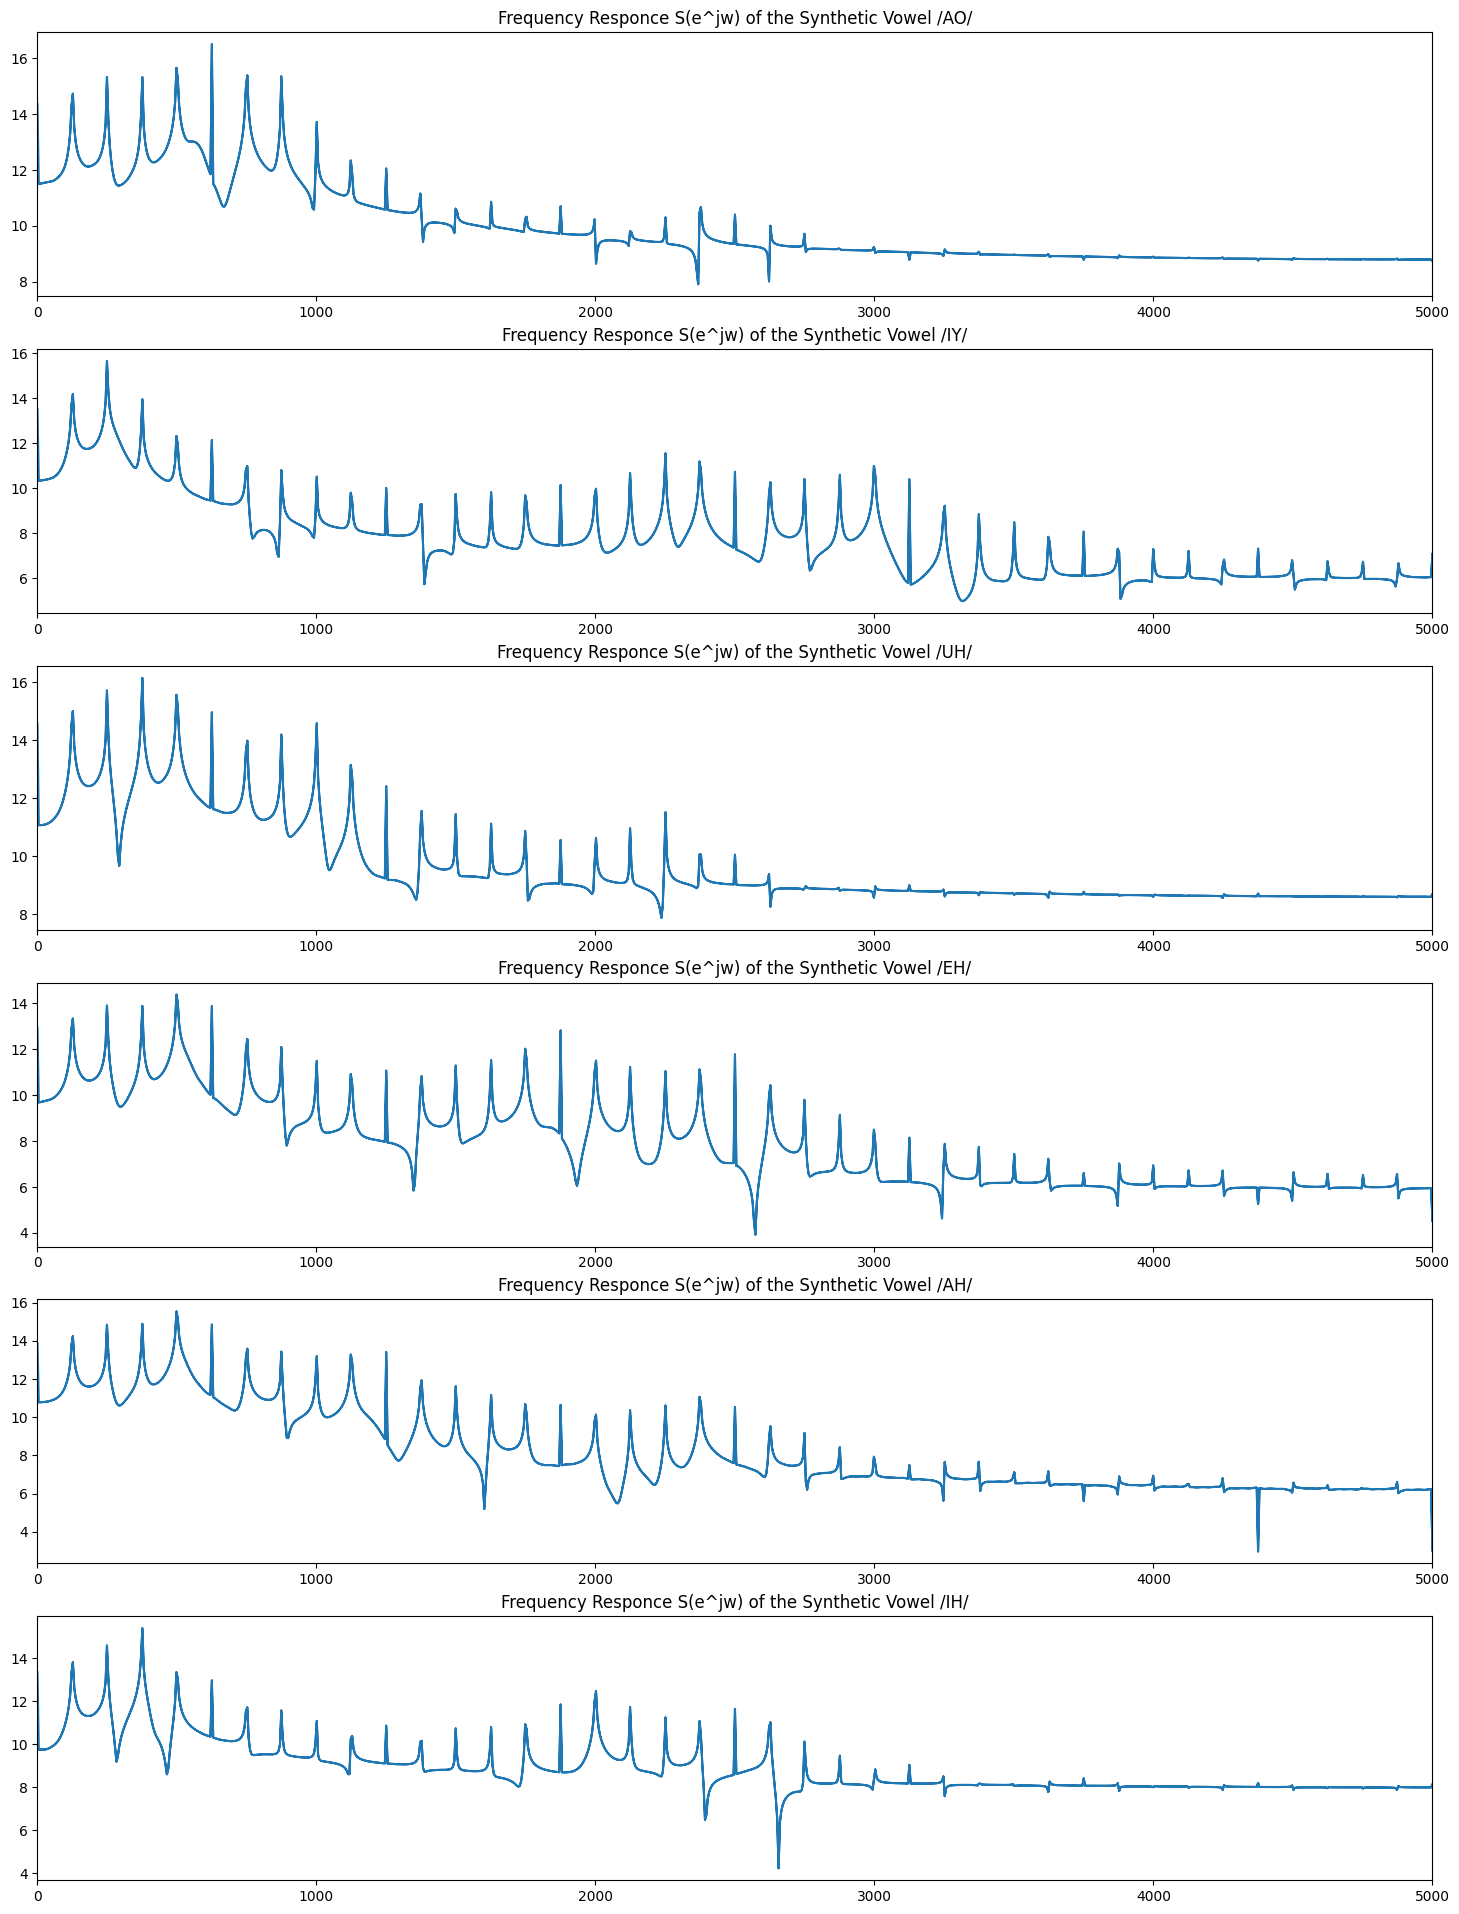

In [235]:
# PLOT ALL SYNTHETIC VOWELS IN FREQUENCY DOMAIN
plt.figure(figsize=(18, 24))

plt.subplot(6, 1, 1)
plt.plot(freqs, sn_fft_magn_ao)
plt.title("Frequency Responce S(e^jw) of the Synthetic Vowel /AO/")
plt.xlim(0, 5000)

plt.subplot(6, 1, 2)
plt.plot(freqs, sn_fft_magn_iy)
plt.title("Frequency Responce S(e^jw) of the Synthetic Vowel /IY/")
plt.xlim(0, 5000)

plt.subplot(6, 1, 3)
plt.plot(freqs, sn_fft_magn_uh)
plt.title("Frequency Responce S(e^jw) of the Synthetic Vowel /UH/")
plt.xlim(0, 5000)

plt.subplot(6, 1, 4)
plt.plot(freqs, sn_fft_magn_eh)
plt.title("Frequency Responce S(e^jw) of the Synthetic Vowel /EH/")
plt.xlim(0, 5000)

plt.subplot(6, 1, 5)
plt.plot(freqs, sn_fft_magn_ah)
plt.title("Frequency Responce S(e^jw) of the Synthetic Vowel /AH/")
plt.xlim(0, 5000)

plt.subplot(6, 1, 6)
plt.plot(freqs, sn_fft_magn_ih)
plt.title("Frequency Responce S(e^jw) of the Synthetic Vowel /IH/")
plt.xlim(0, 5000)

plt.savefig("images/synthetic_voewls_freq.png")
plt.show()

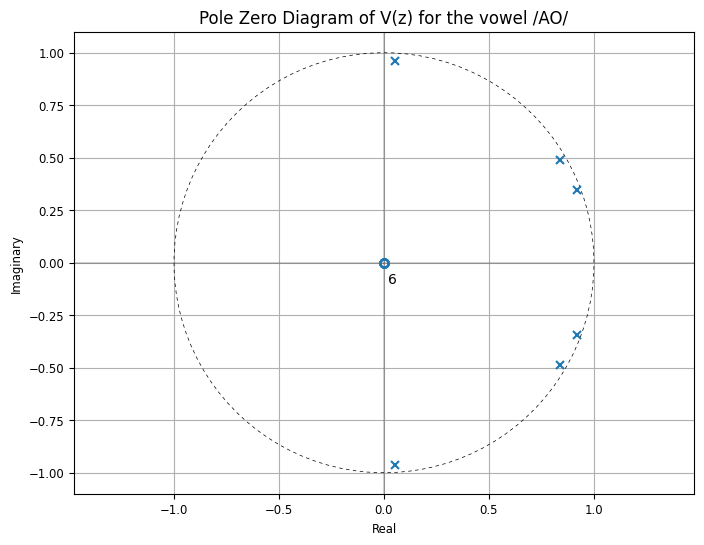

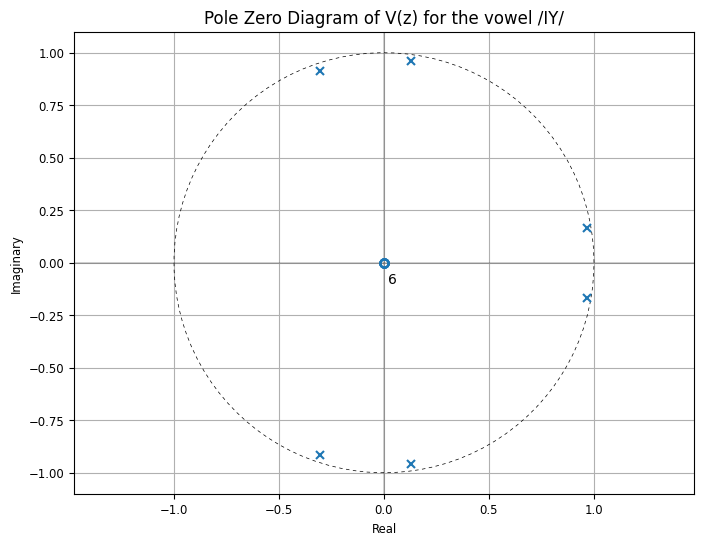

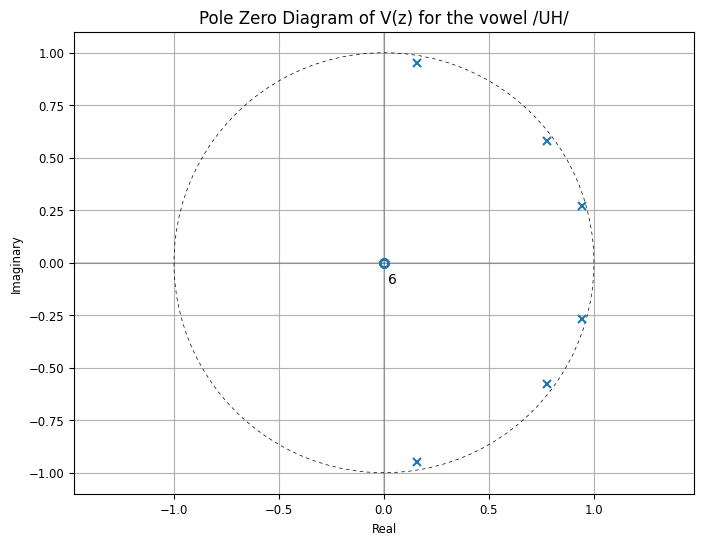

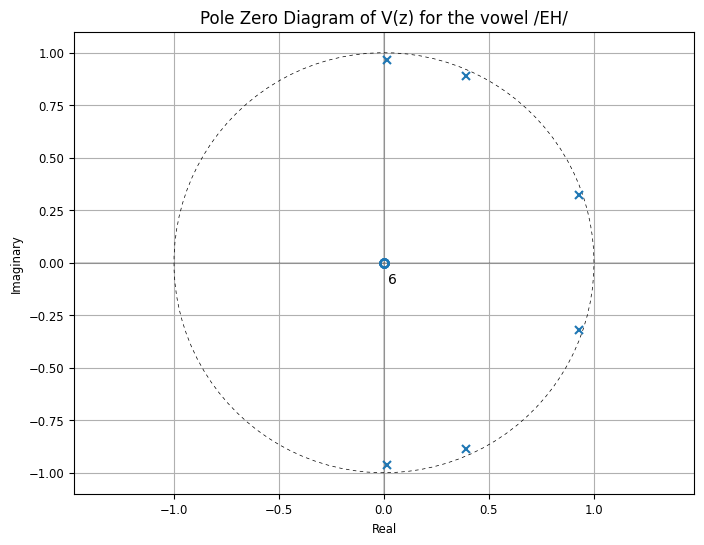

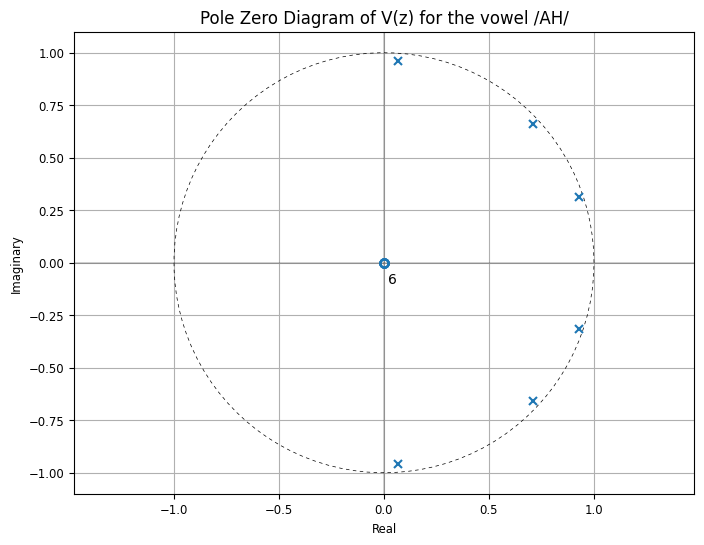

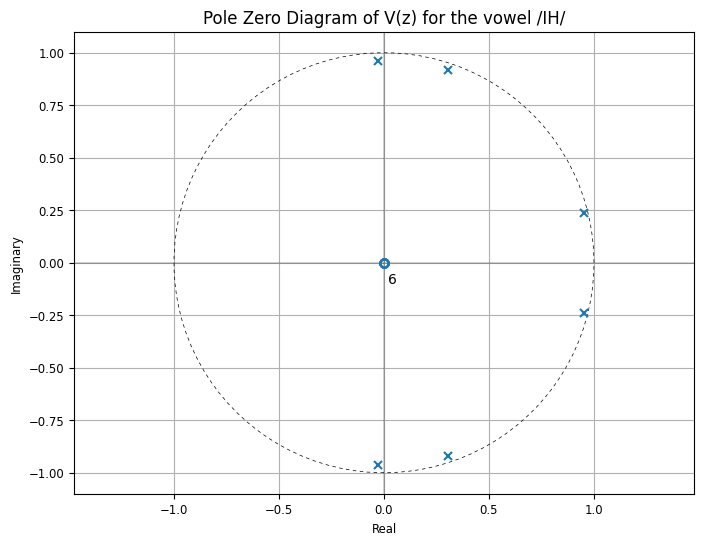

In [236]:
# CREATE AND PLOT THE POLE-ZERO DIAGRAMS OF THE VOCAL TRACT V(z) FOR EACH VOWEL
pole_zero_diagram(vz_num_ao, vz_den_ao, 'Pole Zero Diagram of V(z) for the vowel /AO/') # Pole Zero Diagram of V(z) for the vowel /AO/
pole_zero_diagram(vz_num_iy, vz_den_iy, 'Pole Zero Diagram of V(z) for the vowel /IY/') # Pole Zero Diagram of V(z) for the vowel /IY/
pole_zero_diagram(vz_num_uh, vz_den_uh, 'Pole Zero Diagram of V(z) for the vowel /UH/') # Pole Zero Diagram of V(z) for the vowel /UH/
pole_zero_diagram(vz_num_eh, vz_den_eh, 'Pole Zero Diagram of V(z) for the vowel /EH/') # Pole Zero Diagram of V(z) for the vowel /EH/
pole_zero_diagram(vz_num_ah, vz_den_ah, 'Pole Zero Diagram of V(z) for the vowel /AH/') # Pole Zero Diagram of V(z) for the vowel /AH/
pole_zero_diagram(vz_num_ih, vz_den_ih, 'Pole Zero Diagram of V(z) for the vowel /IH/') # Pole Zero Diagram of V(z) for the vowel /IH/

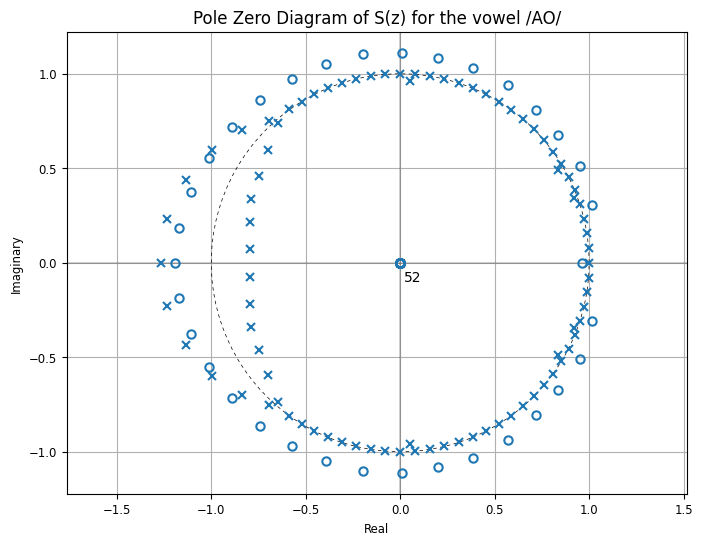

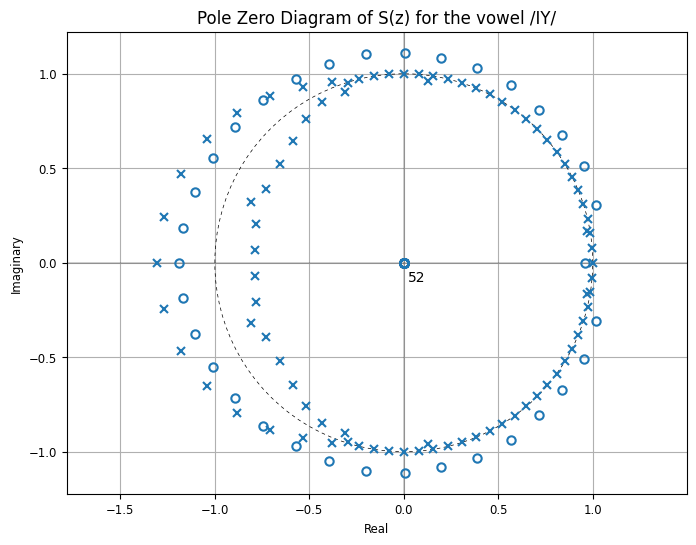

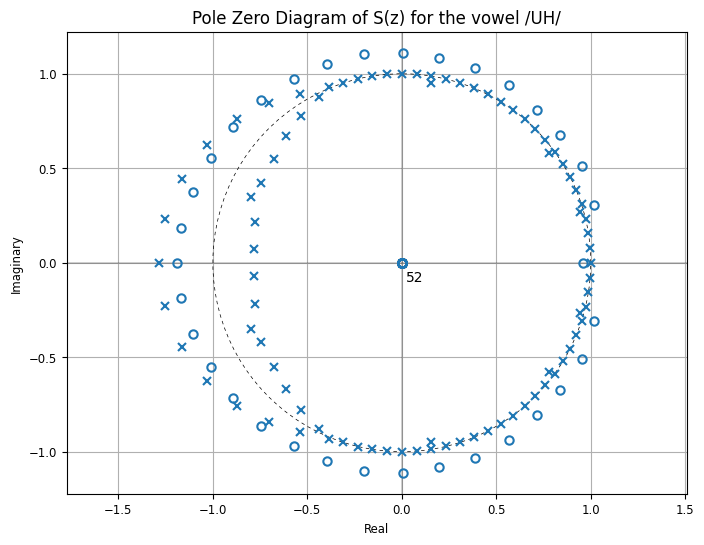

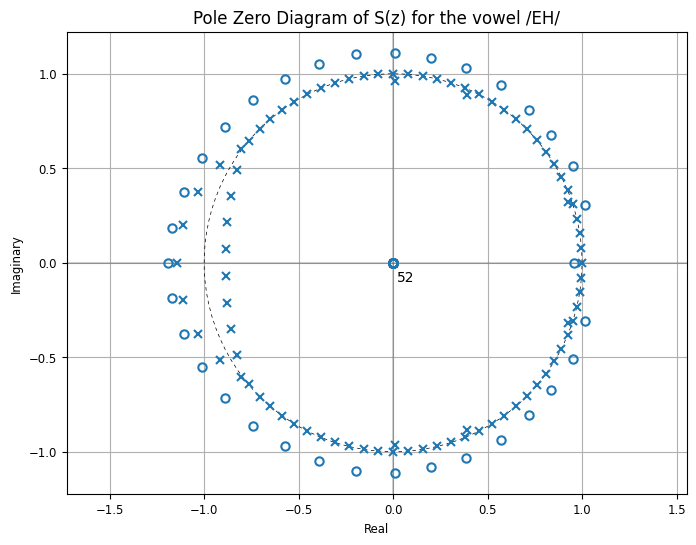

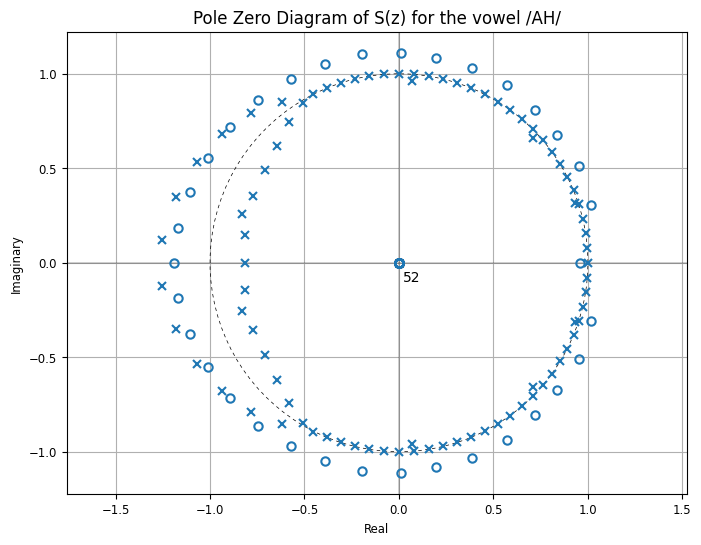

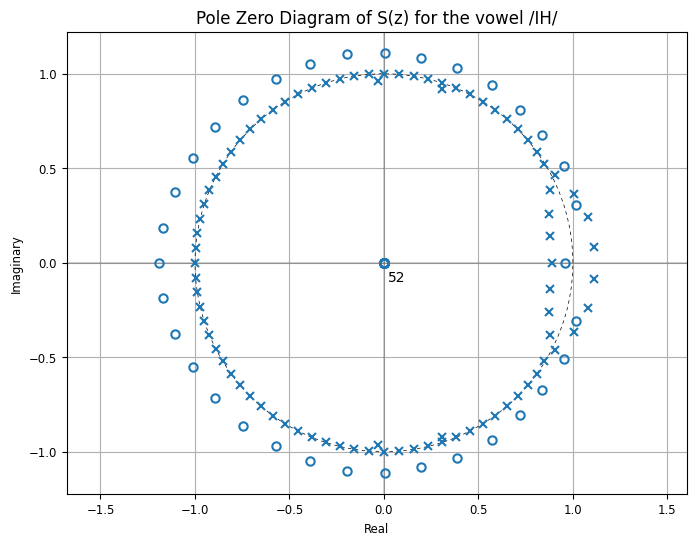

In [237]:
# CREATE AND PLOT THE POLE-ZERO DIAGRAMS FOR EACH SYNTHETIC VOWEL
pole_zero_diagram_of_sz(pz_num, pz_den, gz_num, gz_den, vz_num_ao, vz_den_ao, rz_num, rz_den, "/AO/") # Pole Zero Diagram of Synthetic Vowel /AO/
pole_zero_diagram_of_sz(pz_num, pz_den, gz_num, gz_den, vz_num_iy, vz_den_iy, rz_num, rz_den, "/IY/") # Pole Zero Diagram of Synthetic Vowel /IY/
pole_zero_diagram_of_sz(pz_num, pz_den, gz_num, gz_den, vz_num_uh, vz_den_uh, rz_num, rz_den, "/UH/") # Pole Zero Diagram of Synthetic Vowel /UH/
pole_zero_diagram_of_sz(pz_num, pz_den, gz_num, gz_den, vz_num_eh, vz_den_eh, rz_num, rz_den, "/EH/") # Pole Zero Diagram of Synthetic Vowel /EH/
pole_zero_diagram_of_sz(pz_num, pz_den, gz_num, gz_den, vz_num_ah, vz_den_ah, rz_num, rz_den, "/AH/") # Pole Zero Diagram of Synthetic Vowel /AH/
pole_zero_diagram_of_sz(pz_num, pz_den, gz_num, gz_den, vz_num_ih, vz_den_ih, rz_num, rz_den, "/IH/") # Pole Zero Diagram of Synthetic Vowel /IH/

In [238]:
# Concatenate all vowels to a single signal, and hear it to verify that the vowels are made successfully
sn = np.concatenate((sn_ao, sn_iy, sn_uh, sn_eh, sn_ah, sn_ih))
ipd.Audio(sn, rate=FS)

In [239]:
# Convert it to 16-bit PCM format (standard for .wav files)
sn_integers = np.int16( (sn/np.max(np.abs(sn))) * 32767 )  # Convert to 16-bit range (and normalize)

# Save as .wav file
write('wav_files/synthetic_vowels.wav', FS, sn_integers)

In [240]:
# Load the recorded vowels with 16kHz sampling rate
speech_vowels, sr = librosa.load("wav_files/speech_vowels.wav", sr=16000)
speech_vowels_trimmed, _ = librosa.effects.trim(speech_vowels) # Trim unnecessary silence/noise
ipd.Audio(speech_vowels_trimmed, rate=sr)

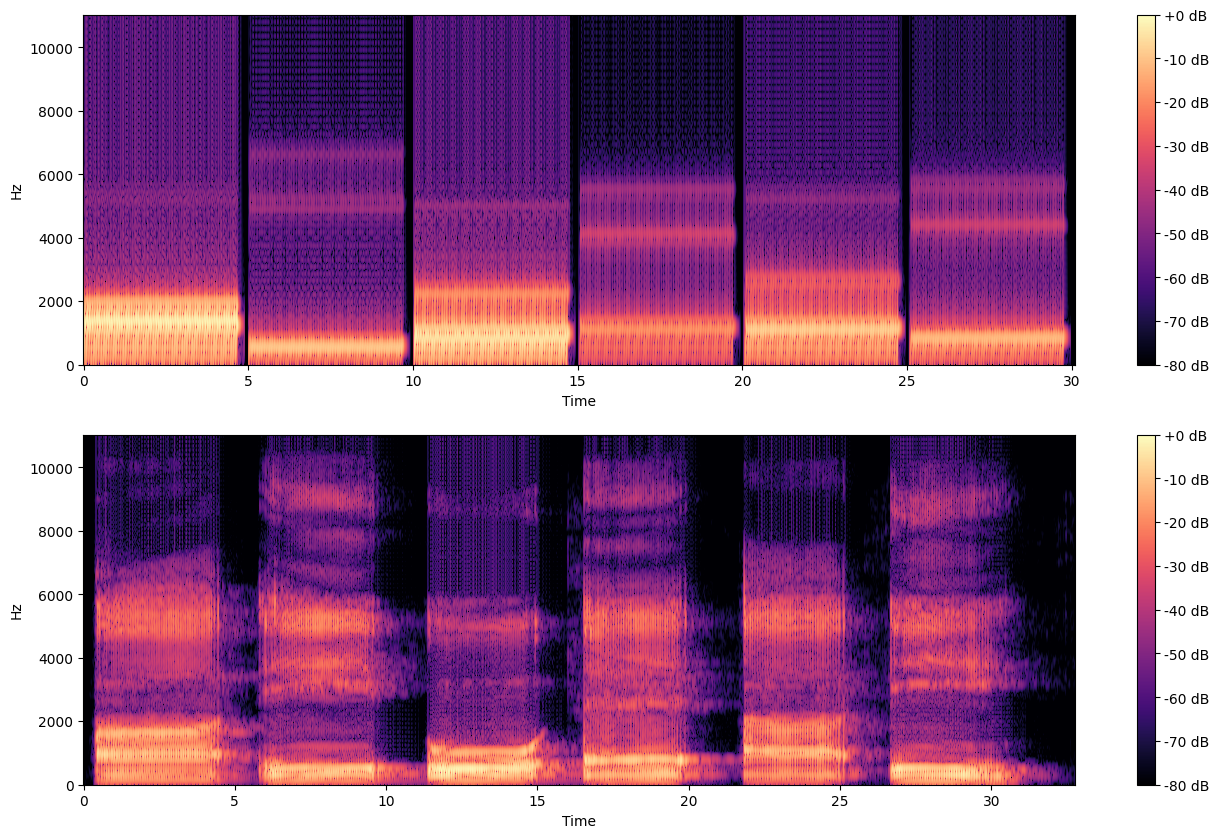

In [243]:
# Create the spectogram of the synthetic vowels and the speech vowels
D_synth = librosa.stft(sn, n_fft=NFFT, hop_length=25, win_length=100, window="hamming") # 100 frames per second with 75% overlap (10kHz sampling rate)
D_speech = librosa.stft(speech_vowels_trimmed, n_fft=NFFT, hop_length=40, win_length=160, window="hamming") # 100 frames per second with 75% overlap (16kHz sampling rate)

S_synth_amp_db = librosa.amplitude_to_db(S=np.abs(D_synth), ref=np.max)
S_speech_amp_db = librosa.amplitude_to_db(S=np.abs(D_speech), ref=np.max)

# And plot both spectograms
plt.figure(figsize=(16, 10))

plt.subplot(2, 1, 1)
librosa.display.specshow(S_synth_amp_db, x_axis='time', y_axis='linear')
plt.colorbar(format='%+2.0f dB')

plt.subplot(2, 1, 2)
librosa.display.specshow(S_speech_amp_db, x_axis='time', y_axis='linear')
plt.colorbar(format='%+2.0f dB')

plt.savefig("images/vowel_spectograms.png")
plt.show()